In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [5]:
uber_15=pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/uber-raw-data-janjune-15_sample.csv')

In [6]:
uber_15.shape

(100000, 4)

In [7]:
uber_15.head()

,Dispatching_base_num,Pickup_date,Affiliated_base_num,locationID
0,B02617,2015-05-02 21:43:00,B02764,237
1,B02682,2015-01-20 19:52:59,B02682,231
2,B02617,2015-03-19 20:26:00,B02617,161
3,B02764,2015-04-10 17:38:00,B02764,107
4,B02764,2015-03-23 07:03:00,B00111,140


In [8]:
type(uber_15)

pandas.core.frame.DataFrame

In [9]:
uber_15.drop_duplicates()
uber_15.duplicated().sum()

np.int64(54)

In [10]:
uber_15.drop_duplicates(inplace=True)
uber_15.duplicated().sum()

np.int64(0)

In [11]:
uber_15.isnull().sum()

,0
Dispatching_base_num,0
Pickup_date,0
Affiliated_base_num,1116
locationID,0


In [12]:
uber_15.dropna(inplace=True)
uber_15.isnull().sum()

,0
Dispatching_base_num,0
Pickup_date,0
Affiliated_base_num,0
locationID,0


In [13]:
type(uber_15['Pickup_date'][0])

str

In [14]:
uber_15['Pickup_date']=pd.to_datetime(uber_15['Pickup_date'])

In [15]:
uber_15['Pickup_date'].dtypes

dtype('<M8[ns]')

In [16]:
uber_15.dtypes

,0
Dispatching_base_num,object
Pickup_date,datetime64[ns]
Affiliated_base_num,object
locationID,int64


In [17]:
uber_15['Pickup_date'].head()

,Pickup_date
0,2015-05-02 21:43:00
1,2015-01-20 19:52:59
2,2015-03-19 20:26:00
3,2015-04-10 17:38:00
4,2015-03-23 07:03:00


In [18]:
uber_15['month']=uber_15['Pickup_date'].dt.month_name()
uber_15['month']

,month
0,May
1,January
2,March
3,April
4,March
...,...
99995,April
99996,March
99997,March
99998,May


In [19]:
uber_15['month'].value_counts()

,count
month,
June,19620
May,18660
April,15982
March,15969
February,15349
January,13250


Text(0, 0.5, 'frequency')

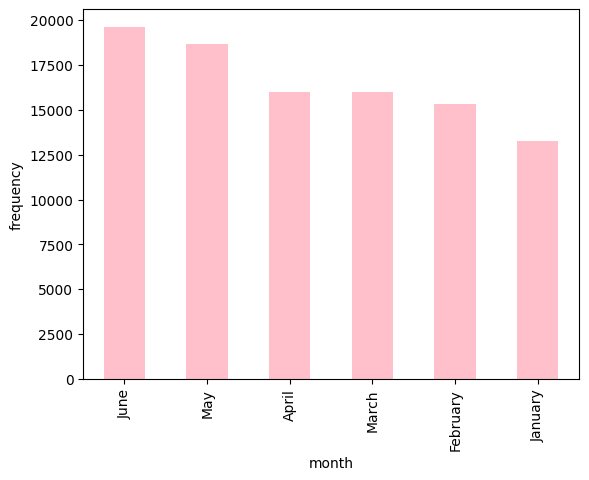

In [21]:
uber_15['month'].value_counts().plot(kind='bar',color='pink')
plt.xlabel('month')
plt.ylabel('frequency')

In [22]:
uber_15['weekday']=uber_15['Pickup_date'].dt.day_name()
uber_15['day']=uber_15['Pickup_date'].dt.day
uber_15['hour']=uber_15['Pickup_date'].dt.hour
uber_15['minute']=uber_15['Pickup_date'].dt.minute
uber_15.head()

,Dispatching_base_num,Pickup_date,Affiliated_base_num,locationID,month,weekday,day,hour,minute
0,B02617,2015-05-02 21:43:00,B02764,237,May,Saturday,2,21,43
1,B02682,2015-01-20 19:52:59,B02682,231,January,Tuesday,20,19,52
2,B02617,2015-03-19 20:26:00,B02617,161,March,Thursday,19,20,26
3,B02764,2015-04-10 17:38:00,B02764,107,April,Friday,10,17,38
4,B02764,2015-03-23 07:03:00,B00111,140,March,Monday,23,7,3


In [23]:
for column in uber_15:
  uber_15.rename(columns={column : column.lower()},inplace=True)
uber_15.head()

,dispatching_base_num,pickup_date,affiliated_base_num,locationid,month,weekday,day,hour,minute
0,B02617,2015-05-02 21:43:00,B02764,237,May,Saturday,2,21,43
1,B02682,2015-01-20 19:52:59,B02682,231,January,Tuesday,20,19,52
2,B02617,2015-03-19 20:26:00,B02617,161,March,Thursday,19,20,26
3,B02764,2015-04-10 17:38:00,B02764,107,April,Friday,10,17,38
4,B02764,2015-03-23 07:03:00,B00111,140,March,Monday,23,7,3


In [24]:
pivot=pd.crosstab(index=uber_15['month'],columns=uber_15['weekday'])
pivot.head()

weekday,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
month,,,,,,,
April,2365,1833,2508,2052,2823,1880,2521
February,2580,1907,2455,2095,2333,2043,1936
January,2414,1300,2614,1573,2287,1389,1673
June,2793,2848,3037,2485,2767,3187,2503
March,2465,2115,2522,2379,2093,2388,2007


Text(0, 0.5, 'weekday')

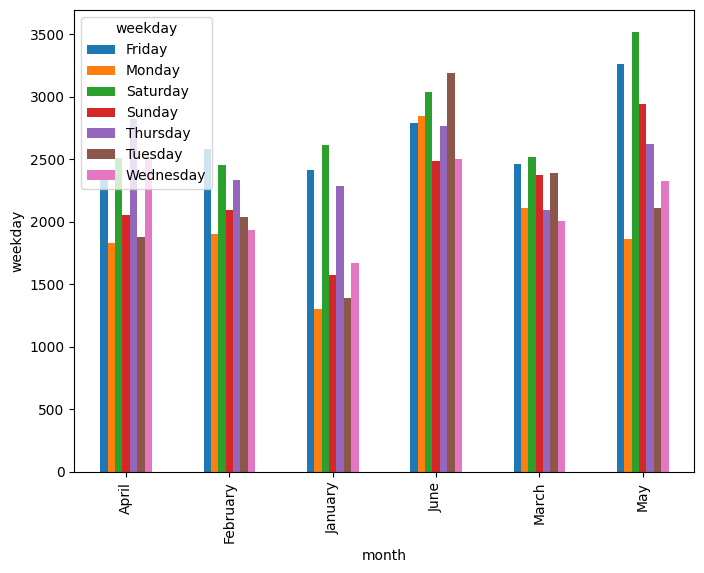

In [25]:
pivot.plot(kind='bar',figsize=(8,6))
plt.xlabel('month')
plt.ylabel('weekday')


In [26]:
summary=uber_15.groupby(['weekday','hour'],as_index=False).size()
summary.head()

,weekday,hour,size
0,Friday,0,576
1,Friday,1,332
2,Friday,2,194
3,Friday,3,137
4,Friday,4,158


In [32]:
pivot2=pd.crosstab(index=uber_15['weekday'],columns=uber_15['hour'])
pivot2.head()

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
weekday,,,,,,,,,,,,,,,,,,,,,
Friday,576,332,194,137,158,218,348,537,708,728,...,620,682,752,968,1096,1195,1178,1001,1091,1202
Monday,335,177,108,100,139,237,347,506,676,653,...,508,562,609,738,816,826,713,742,633,474
Saturday,1024,672,503,350,247,168,190,229,326,413,...,664,651,867,989,1065,1172,1106,1117,1188,1268
Sunday,1107,880,612,427,285,189,171,192,252,332,...,708,692,719,798,734,704,688,608,648,563
Thursday,471,243,177,111,139,181,351,539,689,695,...,550,681,771,962,1151,1085,1080,1050,1032,933


<Axes: xlabel='hour', ylabel='size'>

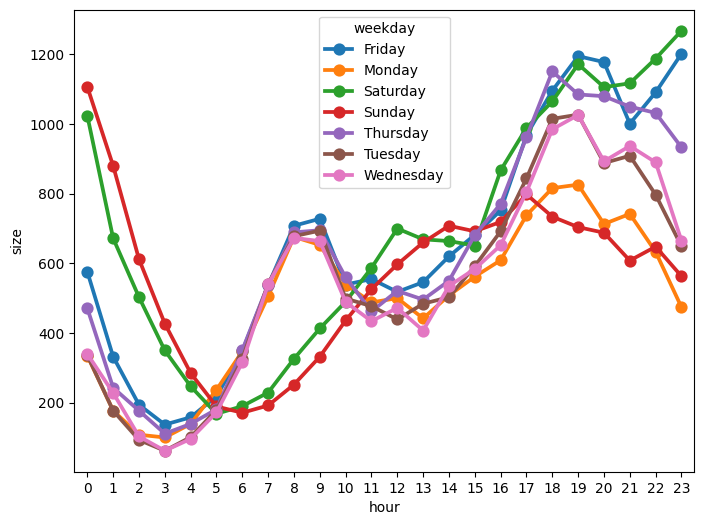

In [29]:
plt.figure(figsize=(8,6))
sns.pointplot(data=summary,x='hour',y='size',hue='weekday')


In [31]:
uber_foil=pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/Uber-Jan-Feb-FOIL.csv')
uber_foil.head()


,dispatching_base_number,date,active_vehicles,trips
0,B02512,1/1/2015,190,1132
1,B02765,1/1/2015,225,1765
2,B02764,1/1/2015,3427,29421
3,B02682,1/1/2015,945,7679
4,B02617,1/1/2015,1228,9537


In [33]:
!pip install chart_studio
import chart_studio.plotly as py
import plotly.graph_objs as go
import plotly.express as px
from plotly.offline import download_plotlyjs, init_notebook_mode, plot, iplot
init_notebook_mode(connected=True)
import plotly.io as pio
pio.renderers.default="colab"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 1.5 MB/s eta 0:00:00


In [35]:
px.box(data_frame=uber_foil,x='dispatching_base_number',y='active_vehicles')

In [36]:
px.violin(data_frame=uber_foil,x='dispatching_base_number',y='active_vehicles')